# Medium Q2 — 中亞鹹海萎縮過程分析（1984–2023）

## 分析策略
- 資料集：**Landsat Collection 2 SR**（1984–2023），以 **MNDWI**（改進型歸一化差異水體指數）萃取水體範圍
- MNDWI = (Green − SWIR1) / (Green + SWIR1)，閾值 > 0 判定為水體
- 代表年份：1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2023
- 輸出：水體範圍對比地圖 + 面積時間序列折線圖 + 縮減百分比

In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

ee.Authenticate()
ee.Initialize(project='silicon-pattern-423512-i3')

In [2]:
# 鹹海 AOI
aoi = ee.Geometry.Rectangle([58.0, 43.0, 62.0, 46.5])

# 代表年份
YEARS = [1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2023]

def get_summer_composite(year):
    """取年份夏季（6–9月）無雲中位數影像，自動選擇 Landsat 5/7/8/9"""
    start = f'{year}-06-01'
    end   = f'{year}-09-30'
    
    def mask_clouds_l57(img):
        qa = img.select('QA_PIXEL')
        mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 5).eq(0))
        return img.updateMask(mask).multiply(0.0000275).add(-0.2)
    
    def mask_clouds_l89(img):
        qa = img.select('QA_PIXEL')
        mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 5).eq(0))
        return img.updateMask(mask).multiply(0.0000275).add(-0.2)
    
    if year <= 1998:
        col = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
               .filterDate(start, end).filterBounds(aoi)
               .map(mask_clouds_l57)
               .select(['SR_B2', 'SR_B5'], ['Green', 'SWIR1']))
    elif year <= 2012:
        col = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
               .filterDate(start, end).filterBounds(aoi)
               .map(mask_clouds_l57)
               .select(['SR_B2', 'SR_B5'], ['Green', 'SWIR1']))
    else:
        col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
               .filterDate(start, end).filterBounds(aoi)
               .map(mask_clouds_l89)
               .select(['SR_B3', 'SR_B6'], ['Green', 'SWIR1']))
    
    median = col.median().clip(aoi)
    mndwi = median.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')
    water = mndwi.gt(0).rename('water')
    return water, mndwi

print('函數定義完成')

函數定義完成


In [3]:
# 計算各代表年份水體面積（km²）
area_records = []
water_images = {}

for year in YEARS:
    water, mndwi = get_summer_composite(year)
    water_images[year] = water
    
    area_m2 = water.multiply(ee.Image.pixelArea()).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=aoi,
        scale=30,
        maxPixels=1e10
    ).get('water').getInfo()
    
    area_km2 = area_m2 / 1e6
    area_records.append({'year': year, 'area_km2': round(area_km2, 1)})
    print(f'{year}: {area_km2:.1f} km²')

df_area = pd.DataFrame(area_records)

1985: 40327.0 km²
1990: 40490.3 km²
1995: 36222.6 km²
2000: 30553.5 km²
2005: 26222.6 km²
2010: 23627.9 km²
2015: 16651.1 km²
2020: 11990.4 km²
2023: 8504.5 km²


In [4]:
# 面積縮減百分比
area_1985 = df_area.loc[df_area.year == 1985, 'area_km2'].values[0]
area_last = df_area.iloc[-1]['area_km2']
reduction_pct = (1 - area_last / area_1985) * 100

print(f'\n1985 年水體面積: {area_1985:.1f} km²')
print(f'{YEARS[-1]} 年水體面積: {area_last:.1f} km²')
print(f'總計縮減: {reduction_pct:.1f}%')


1985 年水體面積: 40327.0 km²
2023 年水體面積: 8504.5 km²
總計縮減: 78.9%


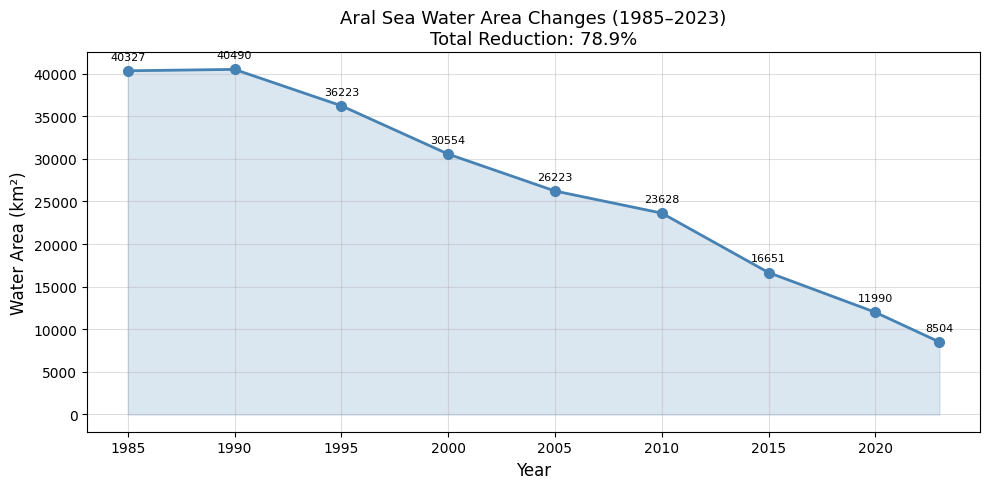

Chart saved as aral_sea_area_timeseries.png


In [8]:
# Water Body Area Time-Series Line Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_area['year'], df_area['area_km2'], 'o-', color='steelblue', linewidth=2, markersize=7)
ax.fill_between(df_area['year'], df_area['area_km2'], alpha=0.2, color='steelblue')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Water Area (km²)', fontsize=12)
ax.set_title(f'Aral Sea Water Area Changes (1985–{YEARS[-1]})\nTotal Reduction: {reduction_pct:.1f}%', fontsize=13)
ax.grid(True, alpha=0.4)

# Add data labels
for _, row in df_area.iterrows():
    ax.annotate(f"{row['area_km2']:.0f}", (row['year'], row['area_km2']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('aral_sea_area_timeseries.png', dpi=150)
plt.show()

print('Chart saved as aral_sea_area_timeseries.png')

In [9]:
# 代表年份水體範圍對比地圖（geemap 多年份展示）
# 選取 1985, 2000, 2010, 2023 四個關鍵年份
key_years = [1985, 2000, 2010, 2023]

Map = geemap.Map(center=[45.0, 60.0], zoom=7)
colors = {'1985': 'blue', '2000': 'cyan', '2010': 'orange', '2023': 'red'}

for yr in key_years:
    w, _ = get_summer_composite(yr)
    Map.addLayer(
        w.updateMask(w),
        {'palette': colors[str(yr)]},
        f'水體 {yr}'
    )

Map

Map(center=[45.0, 60.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [7]:
# 輸出面積表格
df_area['縮減率 vs 1985 (%)'] = ((1 - df_area['area_km2'] / area_1985) * 100).round(1)
print('\n===== 鹹海水體面積彙整 =====')
print(df_area.to_string(index=False))


===== 鹹海水體面積彙整 =====
 year  area_km2  縮減率 vs 1985 (%)
 1985   40327.0              0.0
 1990   40490.3             -0.4
 1995   36222.6             10.2
 2000   30553.5             24.2
 2005   26222.6             35.0
 2010   23627.9             41.4
 2015   16651.1             58.7
 2020   11990.4             70.3
 2023    8504.5             78.9
